# Notebook 08 : Temporalité des corrections TLE
# TLE Correction Timing Analysis

**Projet :** OJS Submission Analytics — Ritsumeikan University (DDSE Lab)  
**Auteur :** Raphael BELY


**CSV utilisé :** `data/processed/atcoder_tle_intervals.csv`

**Structure :**
- **S0** : Distribution des délais entre TLE et soumission suivante (zoom 0–2h, 12 bins de 10 min)
- **S1** : Outcome suivant selon le délai de réflexion — vue globale par niveau (A→F)
- **S1b–S1f** : Même analyse par groupe (G2–G6), un subplot par niveau (B→F)
- **S2** : Outcome suivant selon la position du TLE dans la séquence (1er, 2e, 3e… essai)

---

**CSV used:** `data/processed/atcoder_tle_intervals.csv`

**Structure:**
- **S0**: Distribution of delays between a TLE and the next submission (0–2h zoom, 12 bins of 10 min)
- **S1**: Next outcome by reflection delay — global view per level (A→F)
- **S1b–S1f**: Same analysis by proficiency group (G2–G6), one subplot per level (B→F)
- **S2**: Next outcome by TLE position in the submission sequence (1st, 2nd, 3rd… attempt)

In [1]:
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from pathlib import Path

DATA_DIR = Path("../data/processed")

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

STATUS_COLORS = {
    "AC":      "#2ecc71",
    "WA":      "#e74c3c",
    "TLE":     "#f39c12",
    "CE":      "#3498db",
    "RE":      "#9b59b6",
    "Other":   "#7f8c8d",
    "Abandon": "#bdc3c7",
}
STATUS_ORDER = ["AC", "WA", "TLE", "RE", "CE", "Other", "Abandon"]

DIFFICULTIES = ["A", "B", "C", "D", "E", "F"]
GROUPS = ["G1", "G2", "G3", "G4", "G5", "G6"]


In [2]:
df = pl.read_csv(DATA_DIR / "atcoder_tle_intervals.csv")

print(f"Shape : {df.shape}")
print(f"Colonnes : {df.columns}")
print()
print(df.head(5))
print()
print("next_status distribution:")
print(df.group_by('next_status').agg(pl.len().alias('n')).sort('n', descending=True))


Shape : (488856, 5)
Colonnes : ['difficulty', 'proficiency_group', 'submission_rank', 'delta_seconds', 'next_status']

shape: (5, 5)
┌────────────┬───────────────────┬─────────────────┬───────────────┬─────────────┐
│ difficulty ┆ proficiency_group ┆ submission_rank ┆ delta_seconds ┆ next_status │
│ ---        ┆ ---               ┆ ---             ┆ ---           ┆ ---         │
│ str        ┆ str               ┆ i64             ┆ i64           ┆ str         │
╞════════════╪═══════════════════╪═════════════════╪═══════════════╪═════════════╡
│ D          ┆ G3                ┆ 1               ┆ null          ┆ Abandon     │
│ D          ┆ G4                ┆ 1               ┆ 174           ┆ WA          │
│ D          ┆ G4                ┆ 3               ┆ 178           ┆ TLE         │
│ D          ┆ G4                ┆ 4               ┆ 12858         ┆ AC          │
│ E          ┆ G2                ┆ 1               ┆ 1695          ┆ WA          │
└────────────┴───────────────────┴───

---
## Section 0 — Distribution des délais entre TLE et soumission suivante
## Time Distribution Between TLE and Next Submission

Combien de temps les utilisateurs attendent-ils avant de resoumettre après un TLE ?
Les soumissions sans suite (Abandon) sont exclues de la distribution des délais mais comptabilisées séparément.
Axe X en minutes, zoom 0–2h (12 bins de 10 min). Les délais au-delà de 2h représentent une minorité des cas.

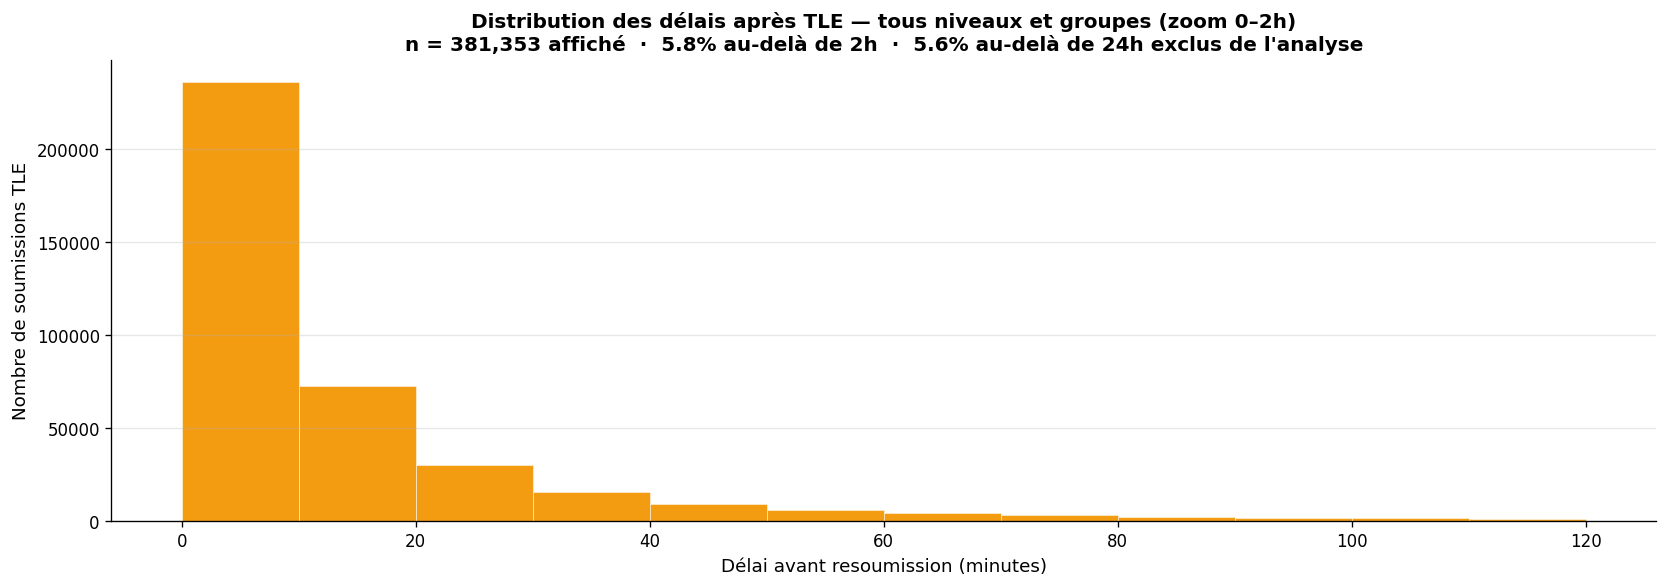

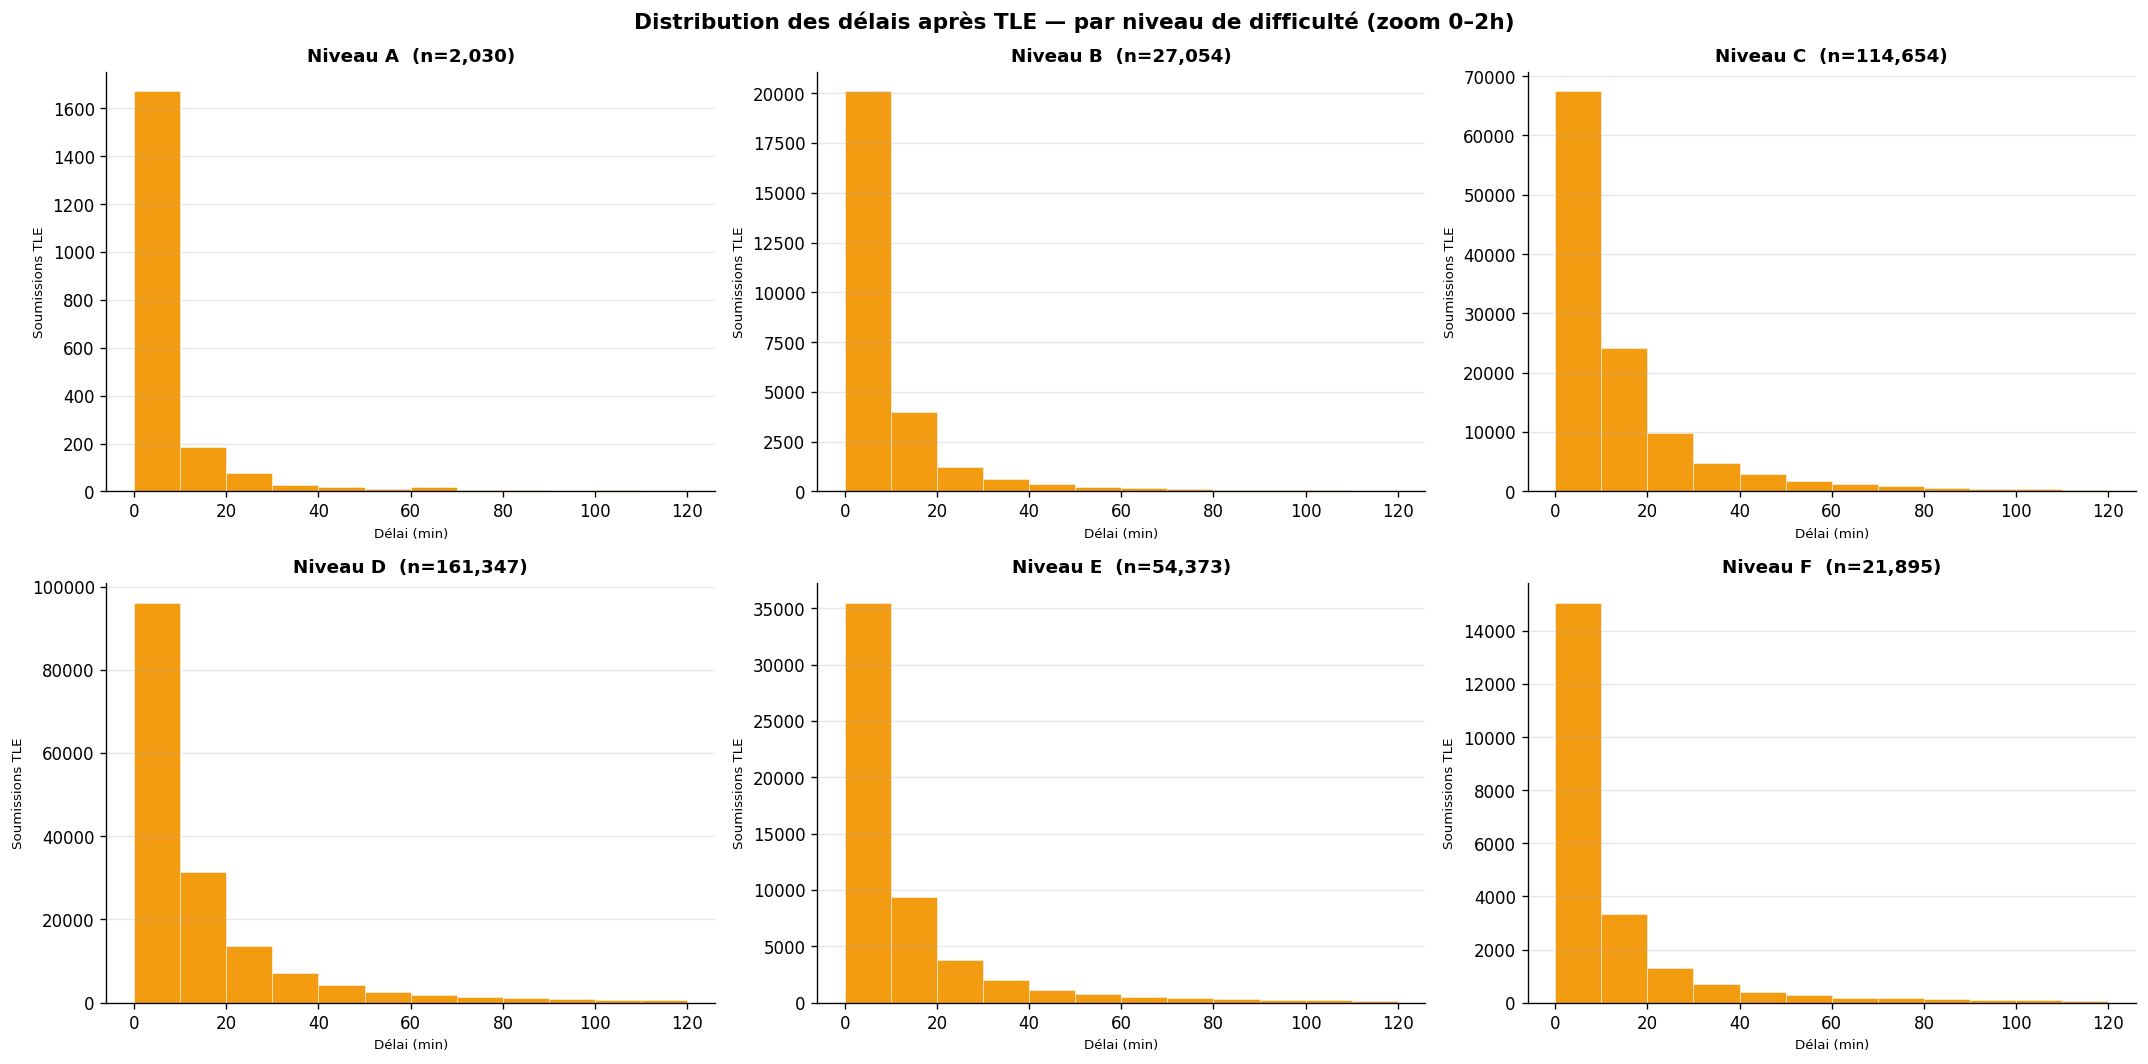

In [3]:
df_timed = df.filter(pl.col('next_status') != 'Abandon').with_columns(
    (pl.col('delta_seconds') / 60).alias('delta_min')
)
df_cap = df_timed.filter(pl.col('delta_min') <= 1440)
pct_beyond_24h = 100 * df_timed.filter(pl.col('delta_min') > 1440).height / df_timed.height

df_plot = df_cap.filter(pl.col('delta_min') <= 120)
pct_beyond_120 = 100 * df_cap.filter(pl.col('delta_min') > 120).height / df_cap.height

bins_lin = np.linspace(0, 120, 13)  # 12 bins de 10 min, 0-120 min (2h)

# --- Figure A : distribution brute (zoom 0-2h) ---
fig, ax = plt.subplots(figsize=(14, 5))
ax.hist(df_plot['delta_min'].to_numpy(), bins=bins_lin,
        color='#f39c12', edgecolor='white', linewidth=0.3)
ax.set_xlabel('Délai avant resoumission (minutes)', fontsize=11)
ax.set_ylabel('Nombre de soumissions TLE', fontsize=11)
ax.set_title(
    f'Distribution des délais après TLE — tous niveaux et groupes (zoom 0–2h)\n'
    f'n = {df_plot.height:,} affiché  ·  {pct_beyond_120:.1f}% au-delà de 2h  ·  '
    f'{pct_beyond_24h:.1f}% au-delà de 24h exclus de l\'analyse',
    fontsize=12, fontweight='bold'
)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# --- Figure B : une courbe par niveau de difficulté ---
fig, axes = plt.subplots(2, 3, figsize=(18, 9), sharey=False)
axes = axes.flatten()

for ax, diff in zip(axes, ['A', 'B', 'C', 'D', 'E', 'F']):
    sub = df_plot.filter(pl.col('difficulty') == diff)
    if sub.height < 100:
        ax.set_visible(False)
        continue
    ax.hist(sub['delta_min'].to_numpy(), bins=bins_lin,
            color='#f39c12', edgecolor='white', linewidth=0.3)
    ax.set_title(f'Niveau {diff}  (n={sub.height:,})', fontsize=11, fontweight='bold')
    ax.set_xlabel('Délai (min)', fontsize=8)
    ax.set_ylabel('Soumissions TLE', fontsize=8)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Distribution des délais après TLE — par niveau de difficulté (zoom 0–2h)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

*Analyse à compléter après exécution / Analysis to be filled after running.*

---
## Section 1 — Résultat suivant un TLE selon le délai de réflexion
## Next Outcome After TLE by Reflection Delay

Pour chaque soumission TLE, on regarde **la soumission immédiatement suivante** (quelle que soit
la position du TLE dans la séquence). Les abandons (aucune soumission suivante) sont exclus.

Chaque barre = un bin temporel. Segments empilés = répartition des outcomes (AC, WA, TLE, RE, CE).
Un graphique par niveau de difficulté (A→F), 2 par ligne.


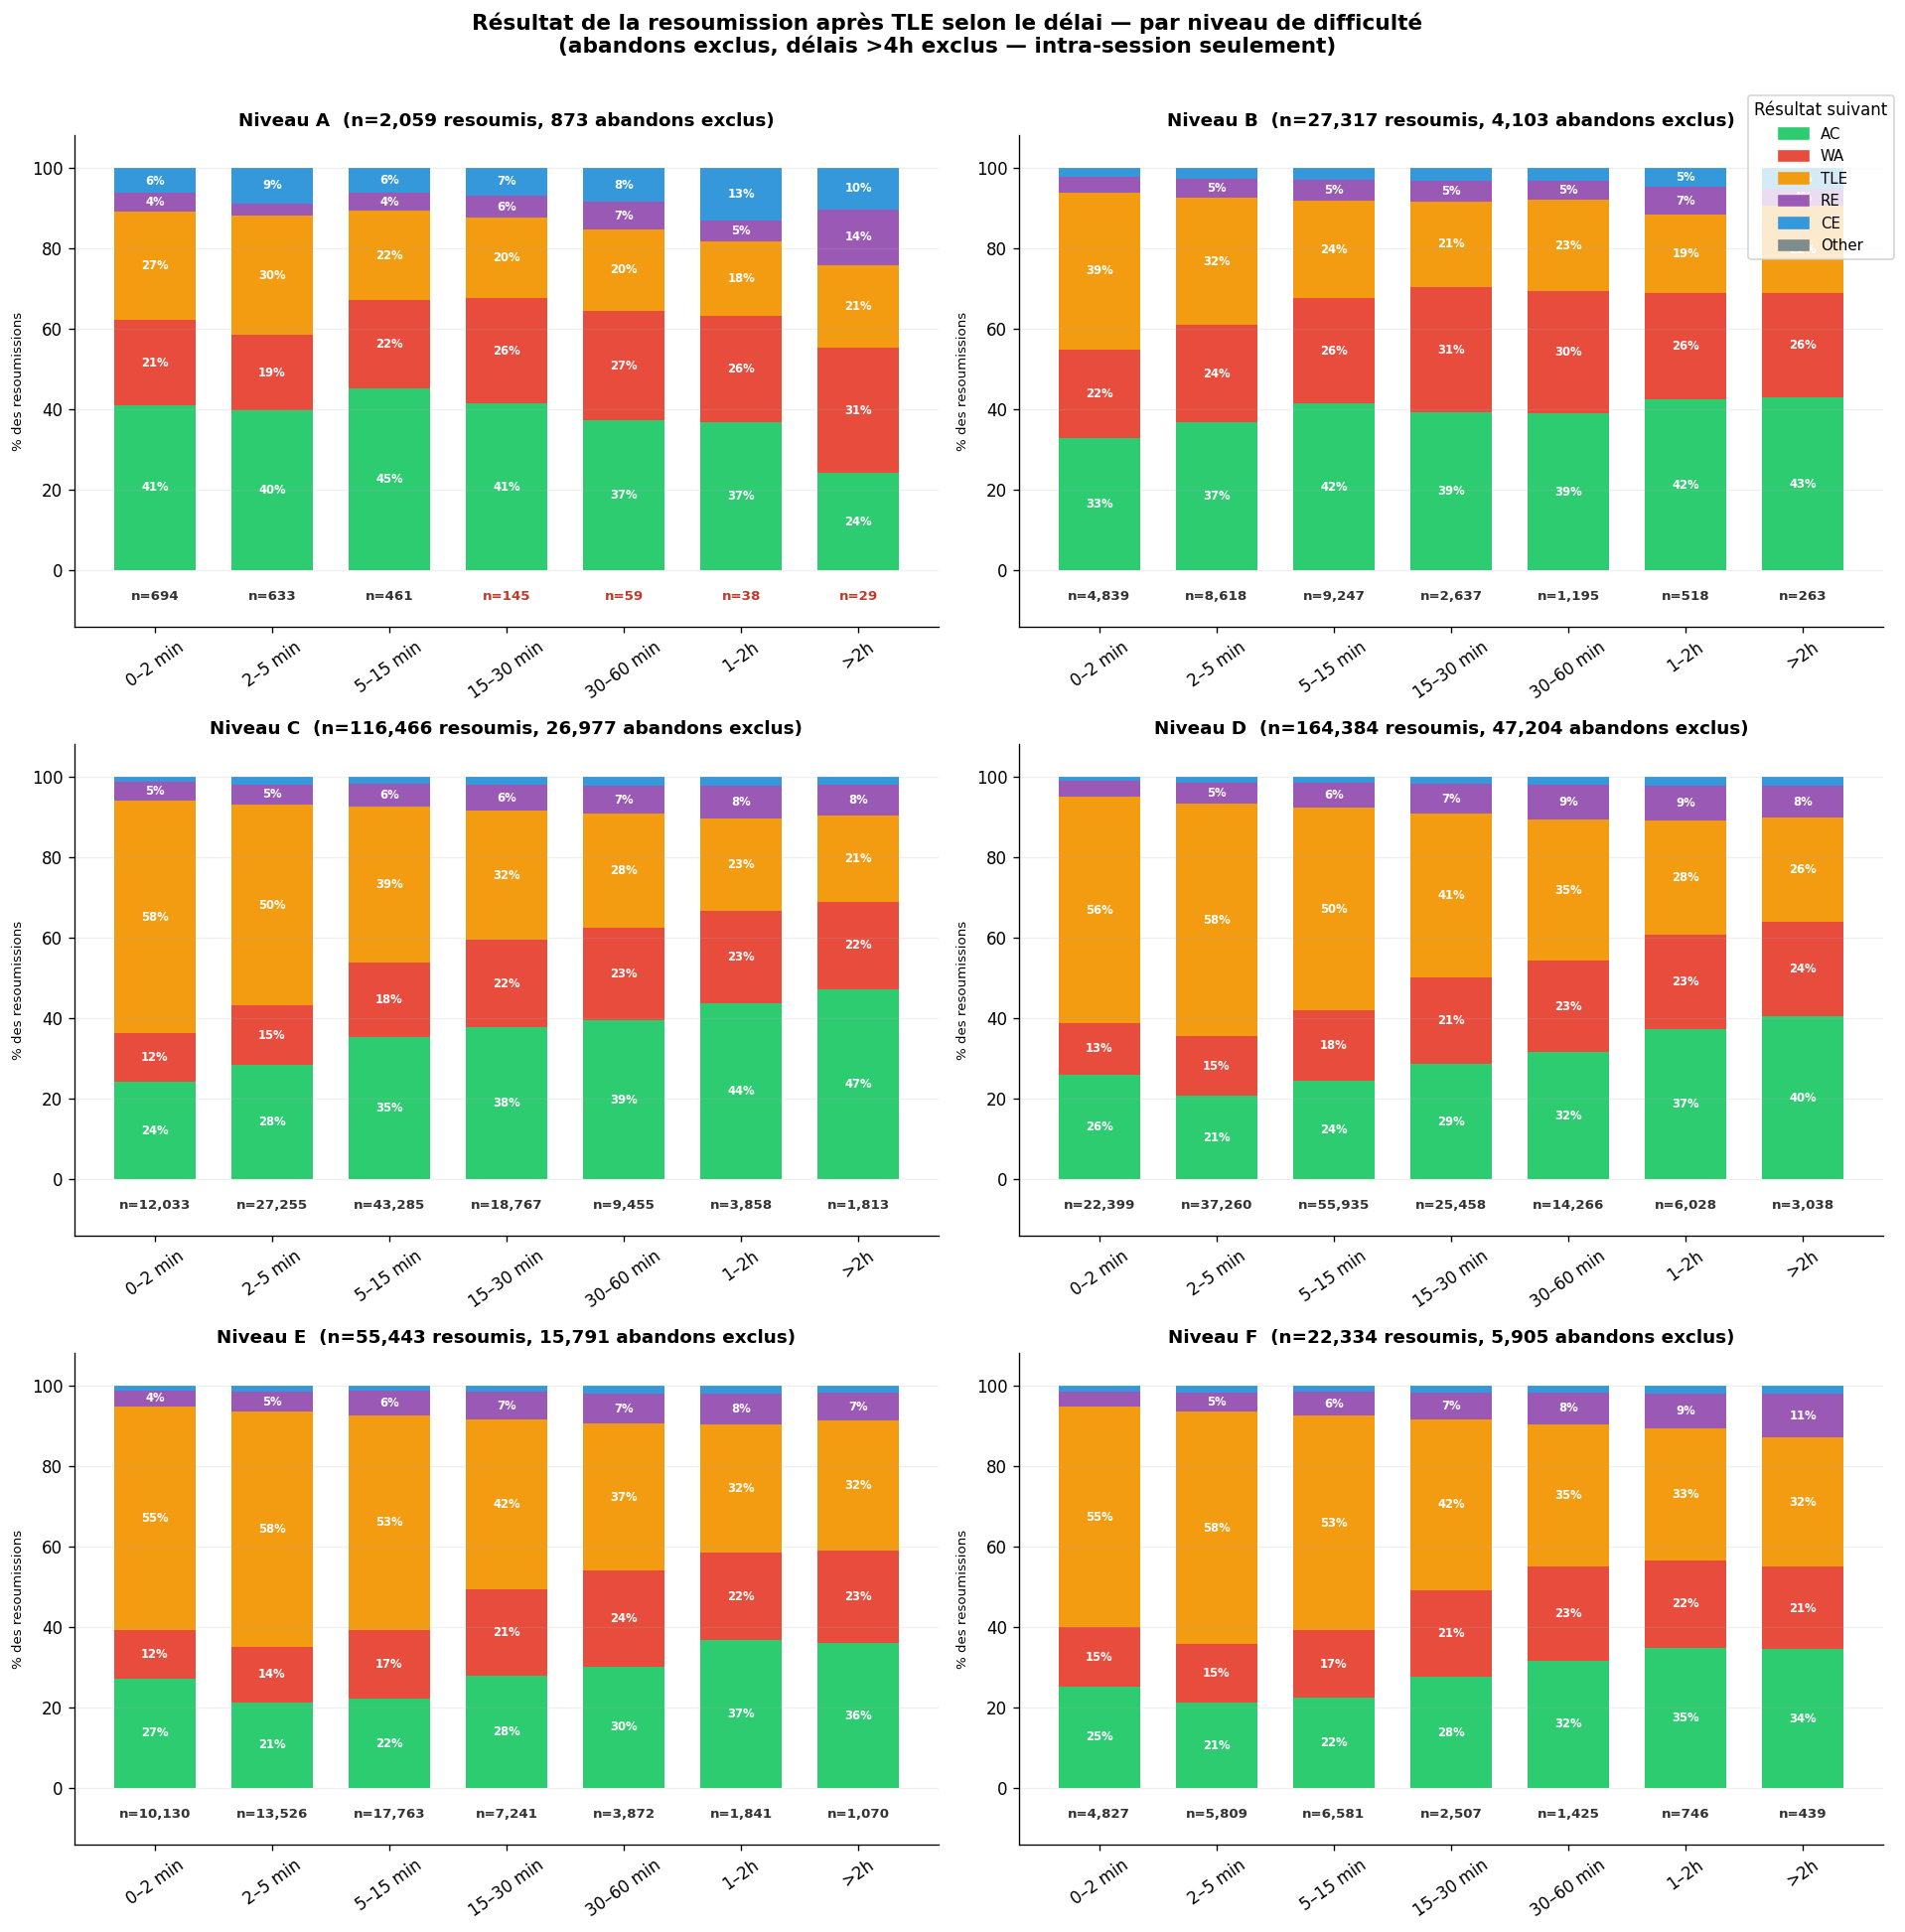

In [4]:
S1_EDGES  = [0, 2, 5, 15, 30, 60, 120, float('inf')]
S1_LABELS = ['0–2 min', '2–5 min', '5–15 min', '15–30 min', '30–60 min', '1–2h', '>2h']
STATUS_OUTCOMES = ['AC', 'WA', 'TLE', 'RE', 'CE', 'Other']

# Filtre global : abandons exclus + intra-session seulement (délai ≤ 4h)
df_s1 = df.filter(
    (pl.col('next_status') != 'Abandon') &
    (pl.col('delta_seconds') <= 14400)
).with_columns((pl.col('delta_seconds') / 60).alias('delta_min'))


def plot_s1(df_input, title, ax):
    bin_counts = {}
    bin_totals = {}
    for j, label in enumerate(S1_LABELS):
        lo, hi = S1_EDGES[j], S1_EDGES[j + 1]
        sub = df_input.filter((pl.col('delta_min') >= lo) & (pl.col('delta_min') < hi))
        n = sub.height
        bin_totals[label] = max(n, 1)
        bin_counts[label] = {s: sub.filter(pl.col('next_status') == s).height
                              for s in STATUS_OUTCOMES}

    bottoms = np.zeros(len(S1_LABELS))
    for status in STATUS_OUTCOMES:
        pcts = np.array([
            100 * bin_counts[l][status] / bin_totals[l]
            for l in S1_LABELS
        ])
        ax.bar(S1_LABELS, pcts, bottom=bottoms,
               color=STATUS_COLORS[status], label=status, width=0.7)

        for i, (pct, bot) in enumerate(zip(pcts, bottoms)):
            if pct > 4:
                ax.text(i, bot + pct / 2, f'{pct:.0f}%',
                        ha='center', va='center', fontsize=7,
                        fontweight='bold', color='white')
        bottoms += pcts

    for i, label in enumerate(S1_LABELS):
        n = bin_totals[label]
        if n > 1:
            clr = '#c0392b' if n < 150 else '#333'
            ax.text(i, -5, f'n={n:,}', ha='center', va='top', fontsize=8,
                    fontweight='bold', color=clr)

    ax.set_ylim(-14, 108)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel('% des resoumissions', fontsize=8)
    ax.tick_params(axis='x', rotation=35)
    ax.grid(axis='y', alpha=0.2)


# 6 niveaux A→F, 2 par ligne → grille 3×2
DIFFS = ['A', 'B', 'C', 'D', 'E', 'F']
fig, axes = plt.subplots(3, 2, figsize=(16, 16))
axes = axes.flatten()

for ax, diff in zip(axes, DIFFS):
    sub = df_s1.filter(pl.col('difficulty') == diff)
    n_total = df.filter(pl.col('difficulty') == diff).height
    n_resubmitted = sub.height
    n_abandon = n_total - n_resubmitted
    if sub.height < 50:
        ax.text(0.5, 0.5, f'Niveau {diff}\ntrop peu de données ({sub.height})',
                ha='center', va='center', transform=ax.transAxes)
        continue
    plot_s1(sub, f'Niveau {diff}  (n={n_resubmitted:,} resoumis, {n_abandon:,} abandons exclus)', ax)

handles = [mpatches.Patch(color=STATUS_COLORS[s], label=s) for s in STATUS_OUTCOMES]
fig.legend(handles=handles, title='Résultat suivant', loc='upper right',
           ncol=1, fontsize=9, bbox_to_anchor=(1.0, 0.97))
fig.suptitle(
    'Résultat de la resoumission après TLE selon le délai — par niveau de difficulté\n'
    '(abandons exclus, délais >4h exclus — intra-session seulement)',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()


*Analyse à compléter après exécution / Analysis to be filled after running.*

---
## Section 1b — Par groupe, niveau B
## By Group, Level B

Groupes affichés : G2, G3, G4, G5, G6 (seuil minimal d'observations respecté).


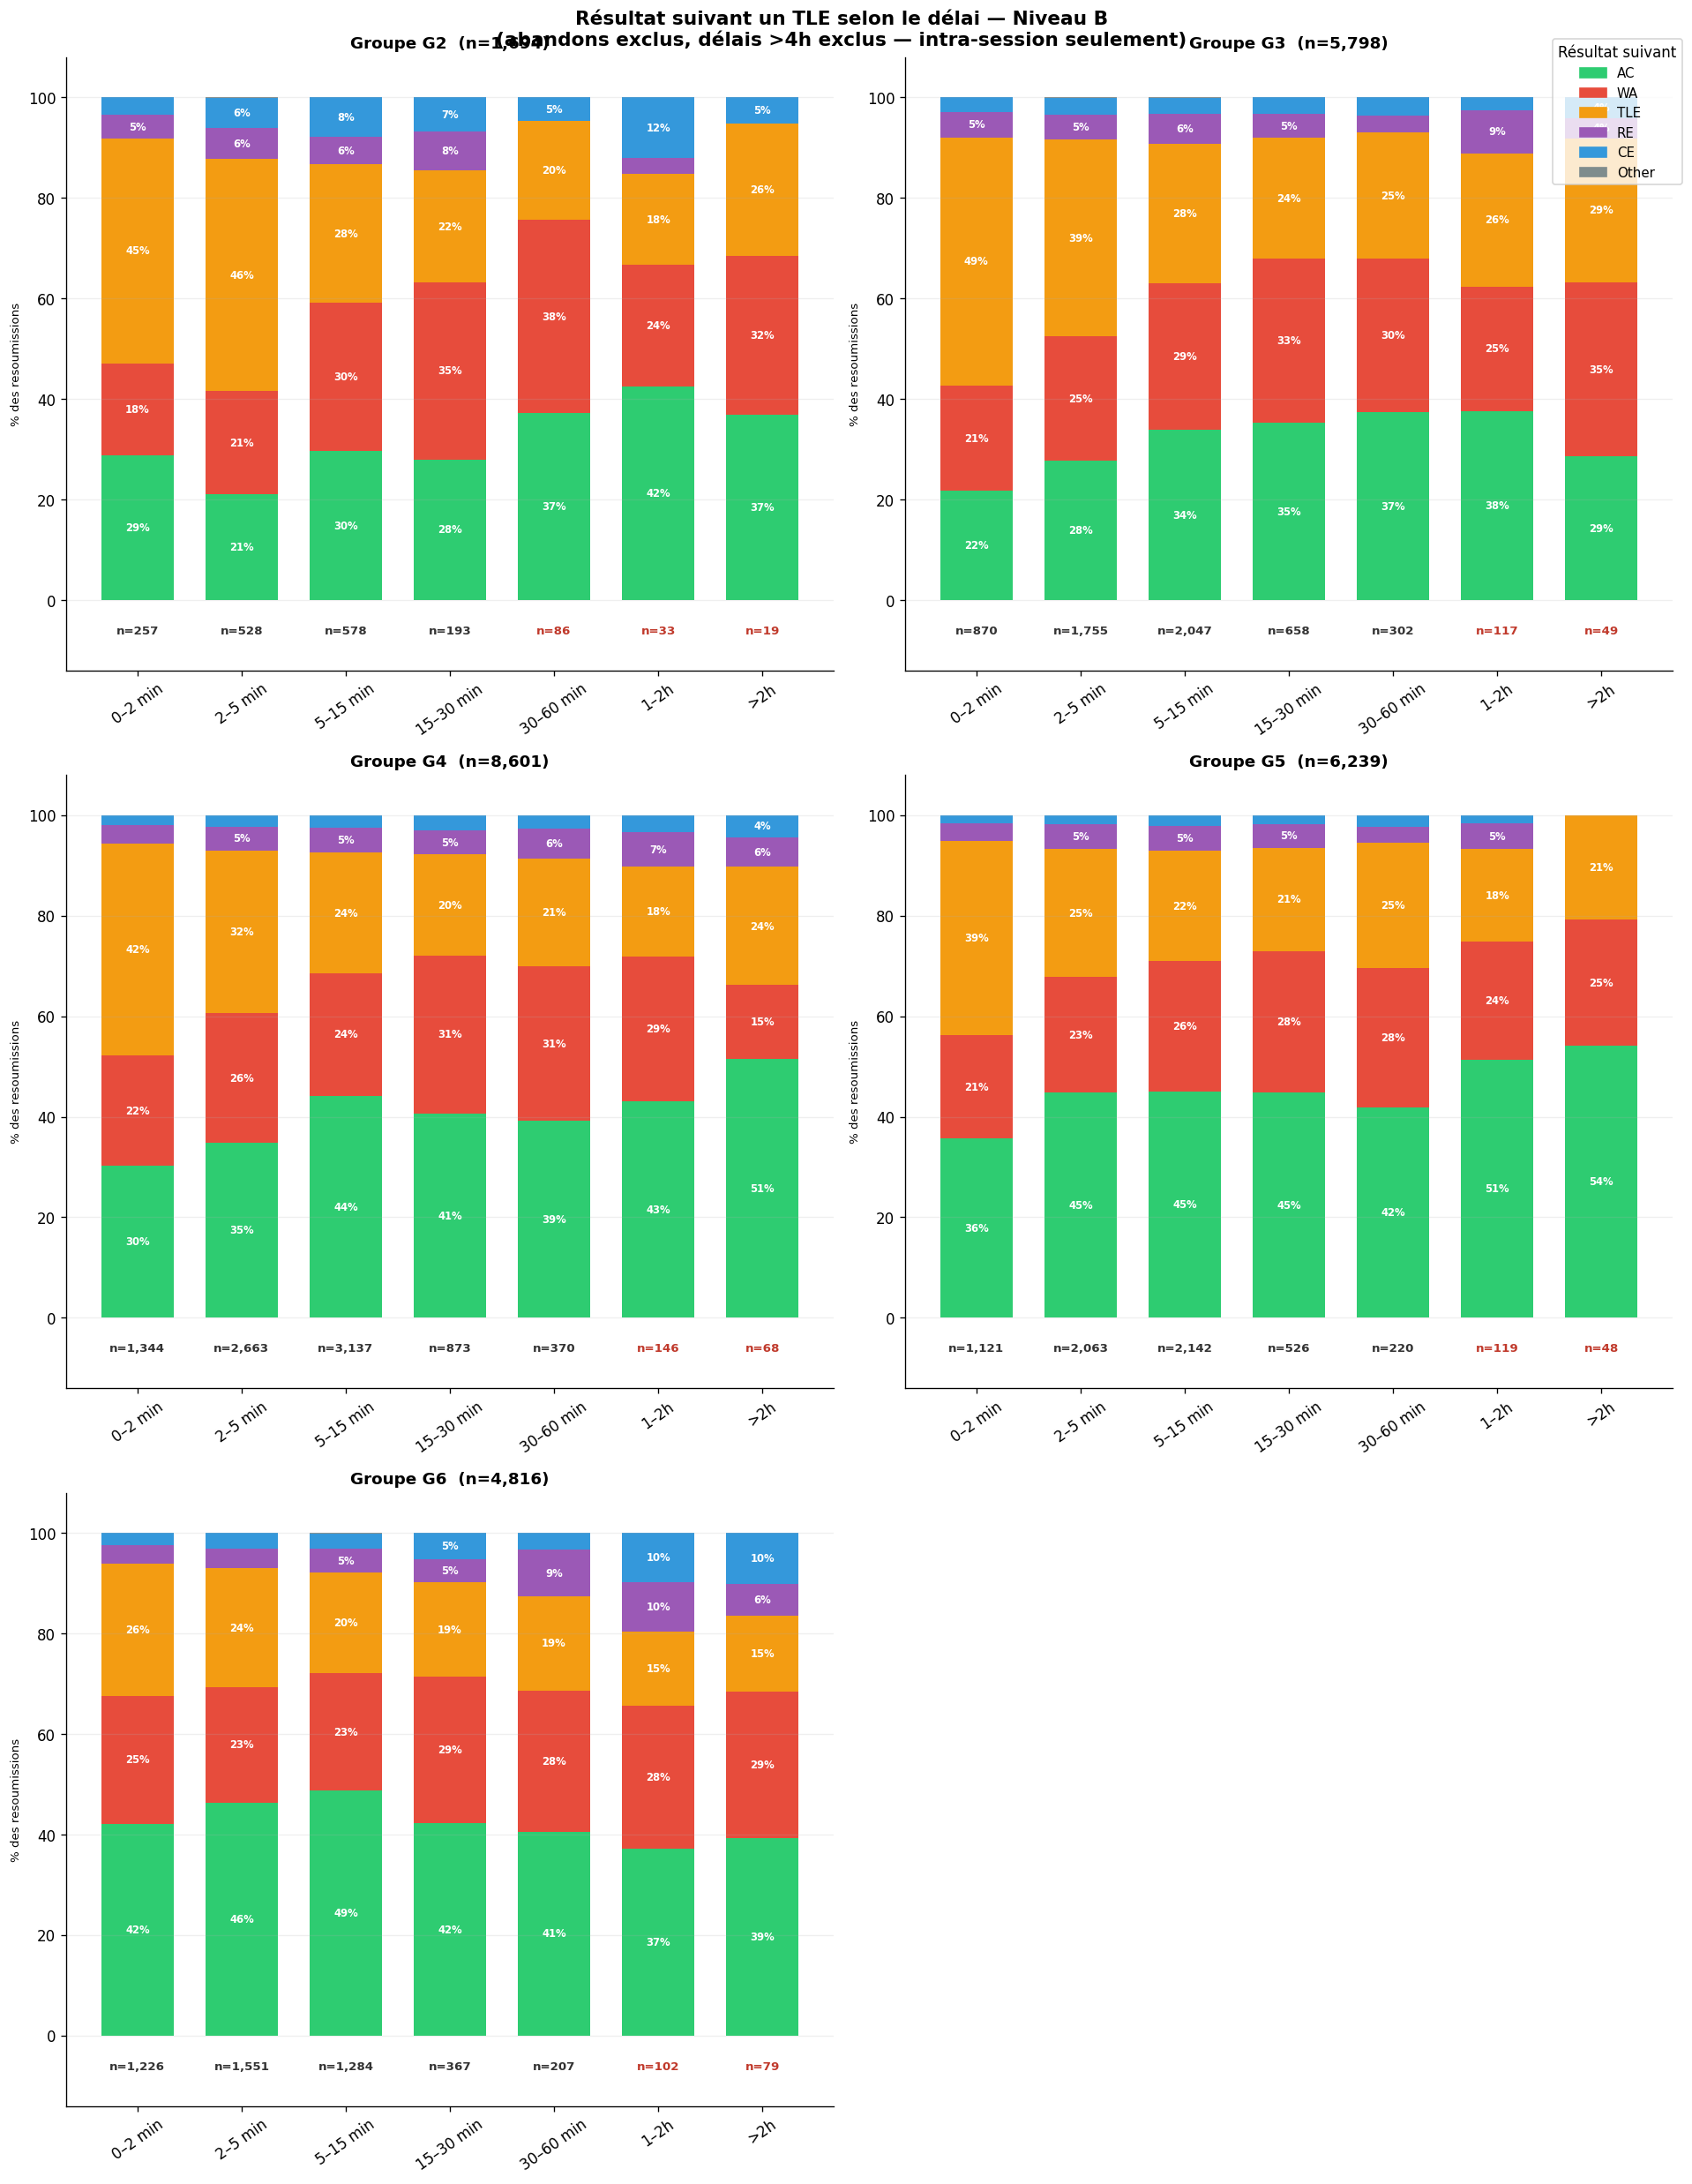

In [5]:
fig, axes = plt.subplots(3, 2, figsize=(16, 21))
axes = np.array(axes).flatten()

df_s1b = df_s1.filter(pl.col('difficulty') == 'B')

for ax, group in zip(axes, ['G2', 'G3', 'G4', 'G5', 'G6']):
    sub = df_s1b.filter(pl.col('proficiency_group') == group)
    plot_s1(sub, f'Groupe {group}  (n={sub.height:,})', ax)

for ax in axes[len(['G2', 'G3', 'G4', 'G5', 'G6']):]:
    ax.set_visible(False)

handles = [mpatches.Patch(color=STATUS_COLORS[s], label=s) for s in STATUS_OUTCOMES]
fig.legend(handles=handles, title='Résultat suivant', loc='upper right',
           ncol=1, fontsize=9, bbox_to_anchor=(1.0, 0.97))
fig.suptitle(
    'Résultat suivant un TLE selon le délai — Niveau B\n'
    '(abandons exclus, délais >4h exclus — intra-session seulement)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()


*Analyse à compléter après exécution / Analysis to be filled after running.*

---
## Section 1c — Par groupe, niveau C
## By Group, Level C

Groupes affichés : G2, G3, G4, G5, G6 (seuil minimal d'observations respecté).


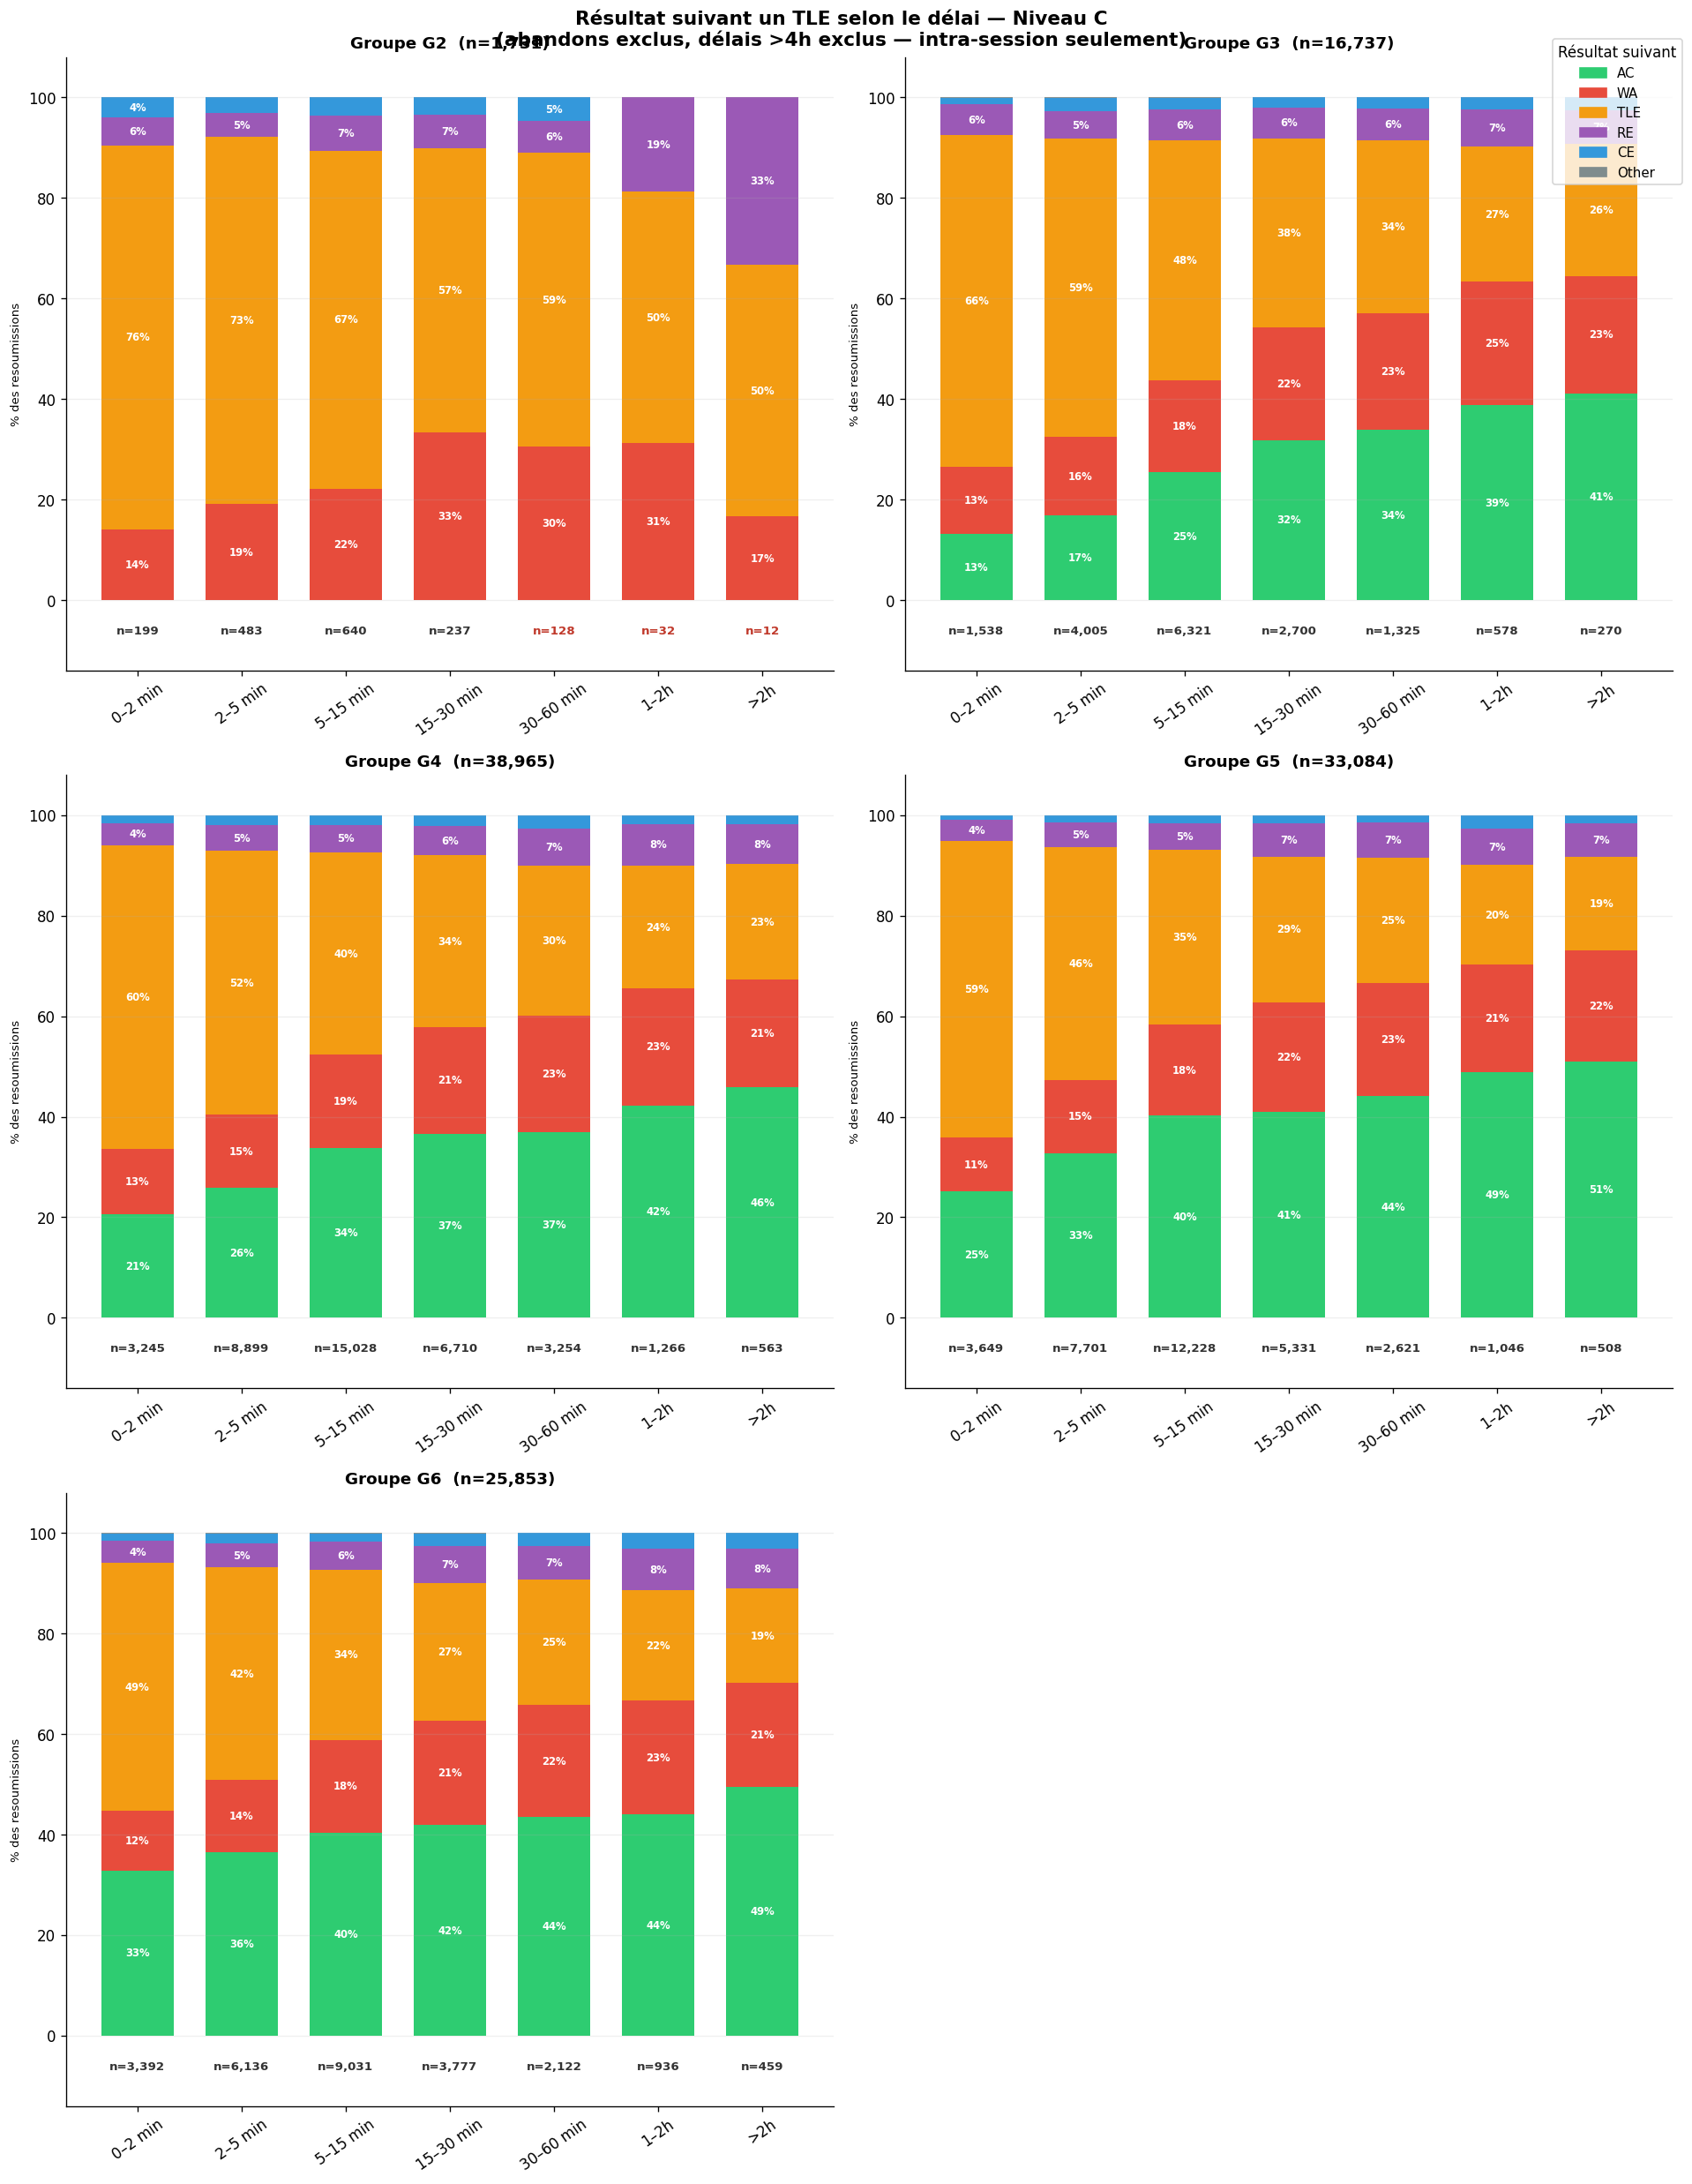

In [6]:
fig, axes = plt.subplots(3, 2, figsize=(16, 21))
axes = np.array(axes).flatten()

df_s1c = df_s1.filter(pl.col('difficulty') == 'C')

for ax, group in zip(axes, ['G2', 'G3', 'G4', 'G5', 'G6']):
    sub = df_s1c.filter(pl.col('proficiency_group') == group)
    plot_s1(sub, f'Groupe {group}  (n={sub.height:,})', ax)

for ax in axes[len(['G2', 'G3', 'G4', 'G5', 'G6']):]:
    ax.set_visible(False)

handles = [mpatches.Patch(color=STATUS_COLORS[s], label=s) for s in STATUS_OUTCOMES]
fig.legend(handles=handles, title='Résultat suivant', loc='upper right',
           ncol=1, fontsize=9, bbox_to_anchor=(1.0, 0.97))
fig.suptitle(
    'Résultat suivant un TLE selon le délai — Niveau C\n'
    '(abandons exclus, délais >4h exclus — intra-session seulement)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()


*Analyse à compléter après exécution / Analysis to be filled after running.*

---
## Section 1d — Par groupe, niveau D
## By Group, Level D

Groupes affichés : G4, G5, G6 (seuil minimal d'observations respecté).


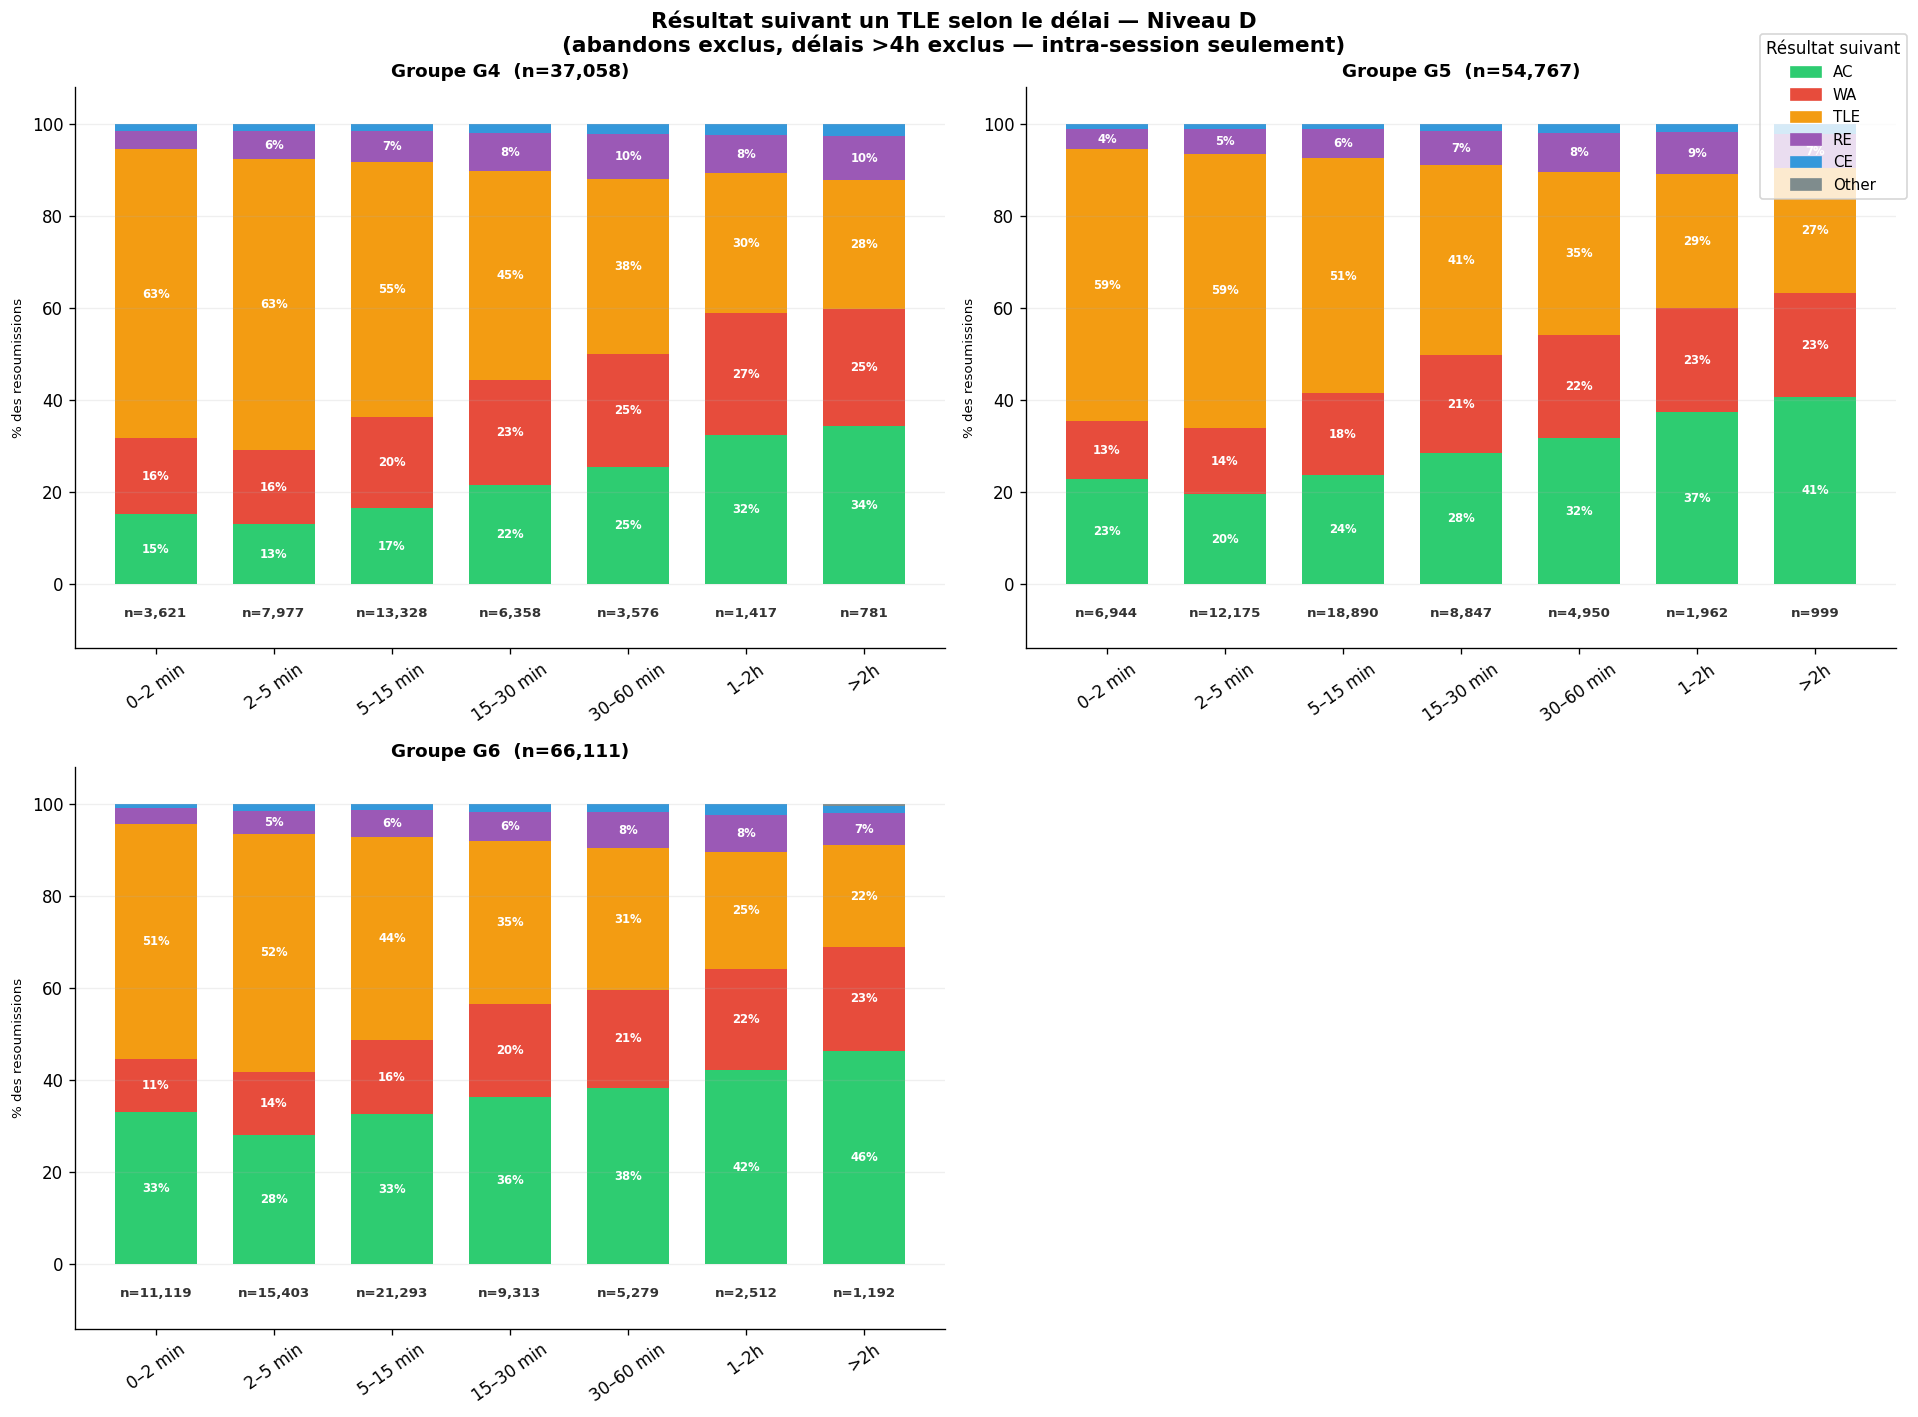

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = np.array(axes).flatten()

df_s1d = df_s1.filter(pl.col('difficulty') == 'D')

for ax, group in zip(axes, ['G4', 'G5', 'G6']):
    sub = df_s1d.filter(pl.col('proficiency_group') == group)
    plot_s1(sub, f'Groupe {group}  (n={sub.height:,})', ax)

axes[3].set_visible(False)

handles = [mpatches.Patch(color=STATUS_COLORS[s], label=s) for s in STATUS_OUTCOMES]
fig.legend(handles=handles, title='Résultat suivant', loc='upper right',
           ncol=1, fontsize=9, bbox_to_anchor=(1.0, 0.97))
fig.suptitle(
    'Résultat suivant un TLE selon le délai — Niveau D\n'
    '(abandons exclus, délais >4h exclus — intra-session seulement)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

*Analyse à compléter après exécution / Analysis to be filled after running.*

---
## Section 1e — Par groupe, niveau E
## By Group, Level E

Groupes affichés : G4, G5, G6 (seuil minimal d'observations respecté).


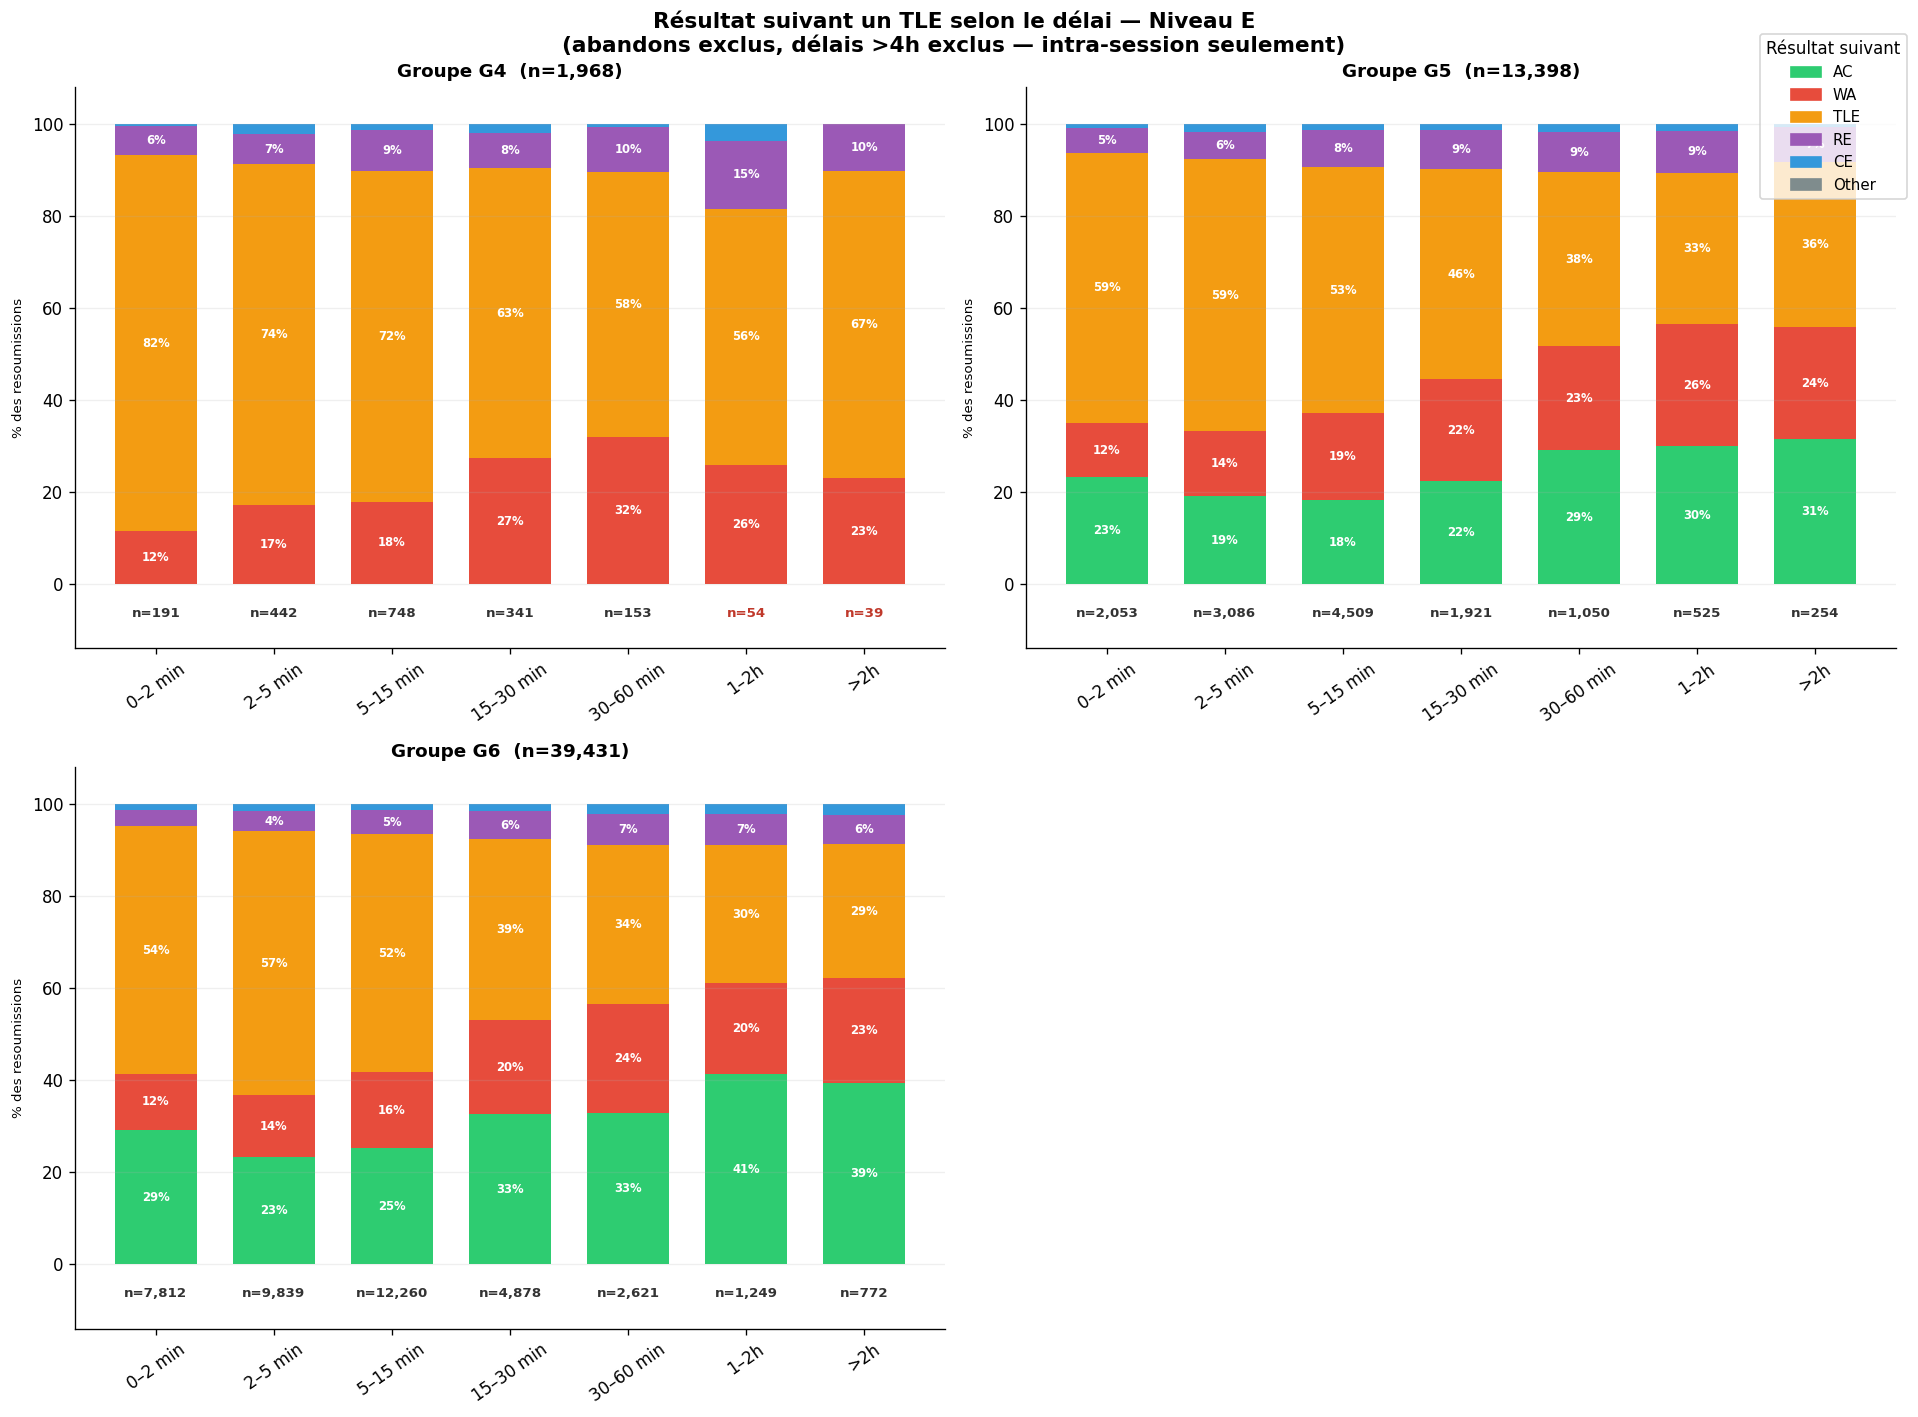

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = np.array(axes).flatten()

df_s1e = df_s1.filter(pl.col('difficulty') == 'E')

for ax, group in zip(axes, ['G4', 'G5', 'G6']):
    sub = df_s1e.filter(pl.col('proficiency_group') == group)
    plot_s1(sub, f'Groupe {group}  (n={sub.height:,})', ax)

axes[3].set_visible(False)

handles = [mpatches.Patch(color=STATUS_COLORS[s], label=s) for s in STATUS_OUTCOMES]
fig.legend(handles=handles, title='Résultat suivant', loc='upper right',
           ncol=1, fontsize=9, bbox_to_anchor=(1.0, 0.97))
fig.suptitle(
    'Résultat suivant un TLE selon le délai — Niveau E\n'
    '(abandons exclus, délais >4h exclus — intra-session seulement)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

*Analyse à compléter après exécution / Analysis to be filled after running.*

---
## Section 1f — Par groupe, niveau F
## By Group, Level F

Groupes affichés : G5, G6 (seuil minimal d'observations respecté).


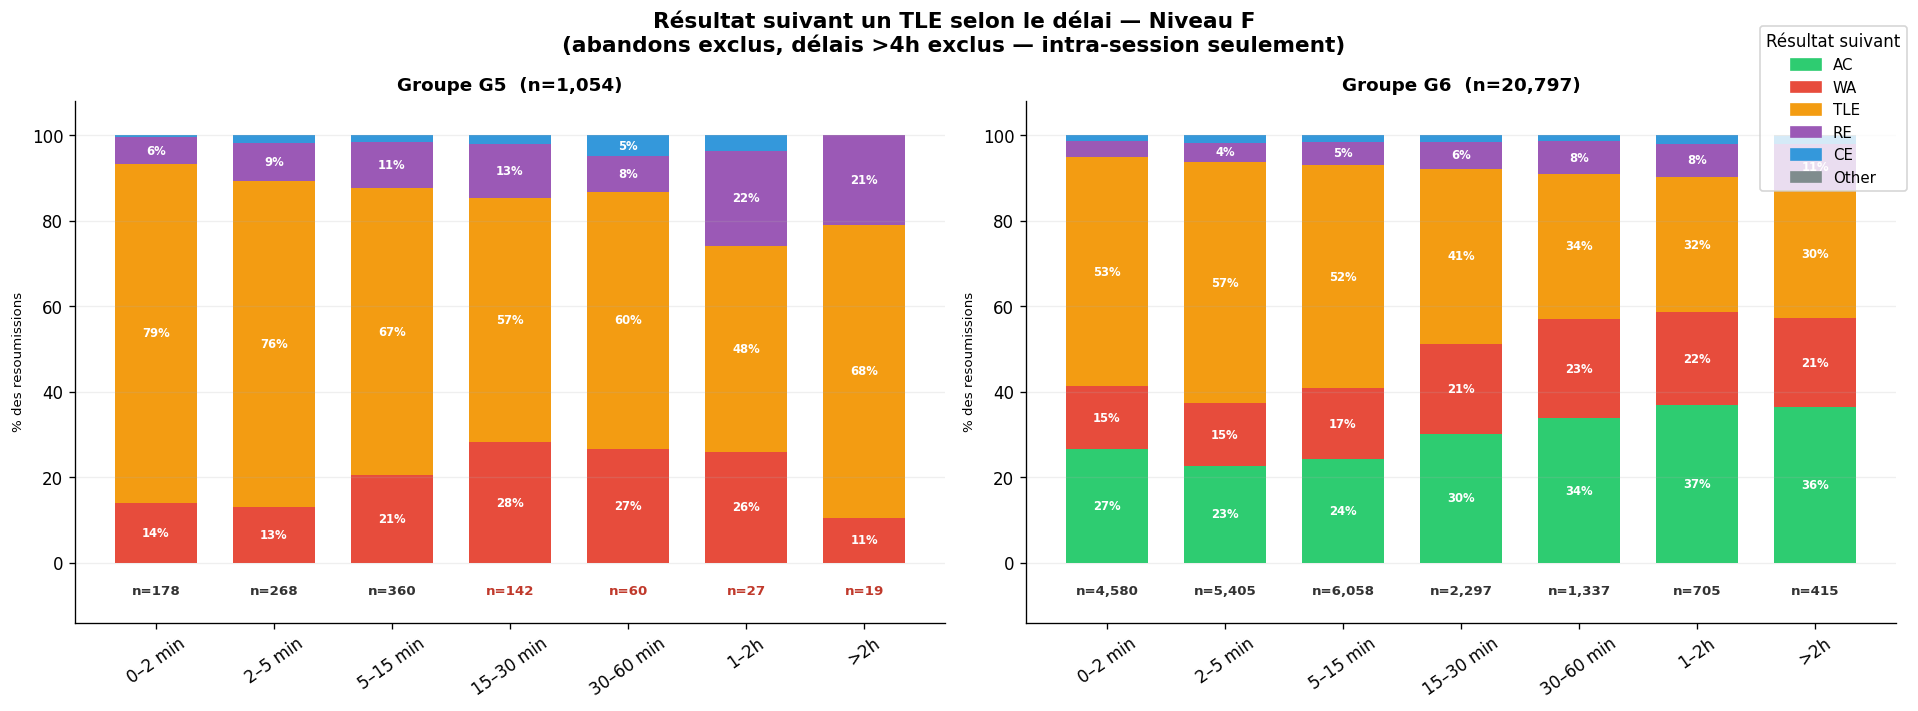

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes = np.array(axes).flatten()

df_s1f = df_s1.filter(pl.col('difficulty') == 'F')

for ax, group in zip(axes, ['G5', 'G6']):
    sub = df_s1f.filter(pl.col('proficiency_group') == group)
    plot_s1(sub, f'Groupe {group}  (n={sub.height:,})', ax)

for ax in axes[len(['G5', 'G6']):]:
    ax.set_visible(False)

handles = [mpatches.Patch(color=STATUS_COLORS[s], label=s) for s in STATUS_OUTCOMES]
fig.legend(handles=handles, title='Résultat suivant', loc='upper right',
           ncol=1, fontsize=9, bbox_to_anchor=(1.0, 0.97))
fig.suptitle(
    'Résultat suivant un TLE selon le délai — Niveau F\n'
    '(abandons exclus, délais >4h exclus — intra-session seulement)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()


*Analyse à compléter après exécution / Analysis to be filled after running.*

---
## Section 2 — Taux d'AC selon la position du TLE dans la séquence
## AC Rate by TLE Position in Submission Sequence

Chaque TLE a un rang dans la séquence de soumissions (user, problème). Position 1 = premier essai était TLE.
Position 5+ = l'utilisateur a déjà soumis ≥4 fois avant ce TLE.

**Hypothèse :** un TLE en début de séquence est plus facile à corriger — l'algorithme est globalement juste,
juste trop lent. Un TLE tardif indique un utilisateur en difficulté qui tourne en rond.

Complément orthogonal à S1 : S1 = dimension temporelle (combien de temps tu réfléchis),
S2 = dimension positionnelle (à quel stade tu en es).


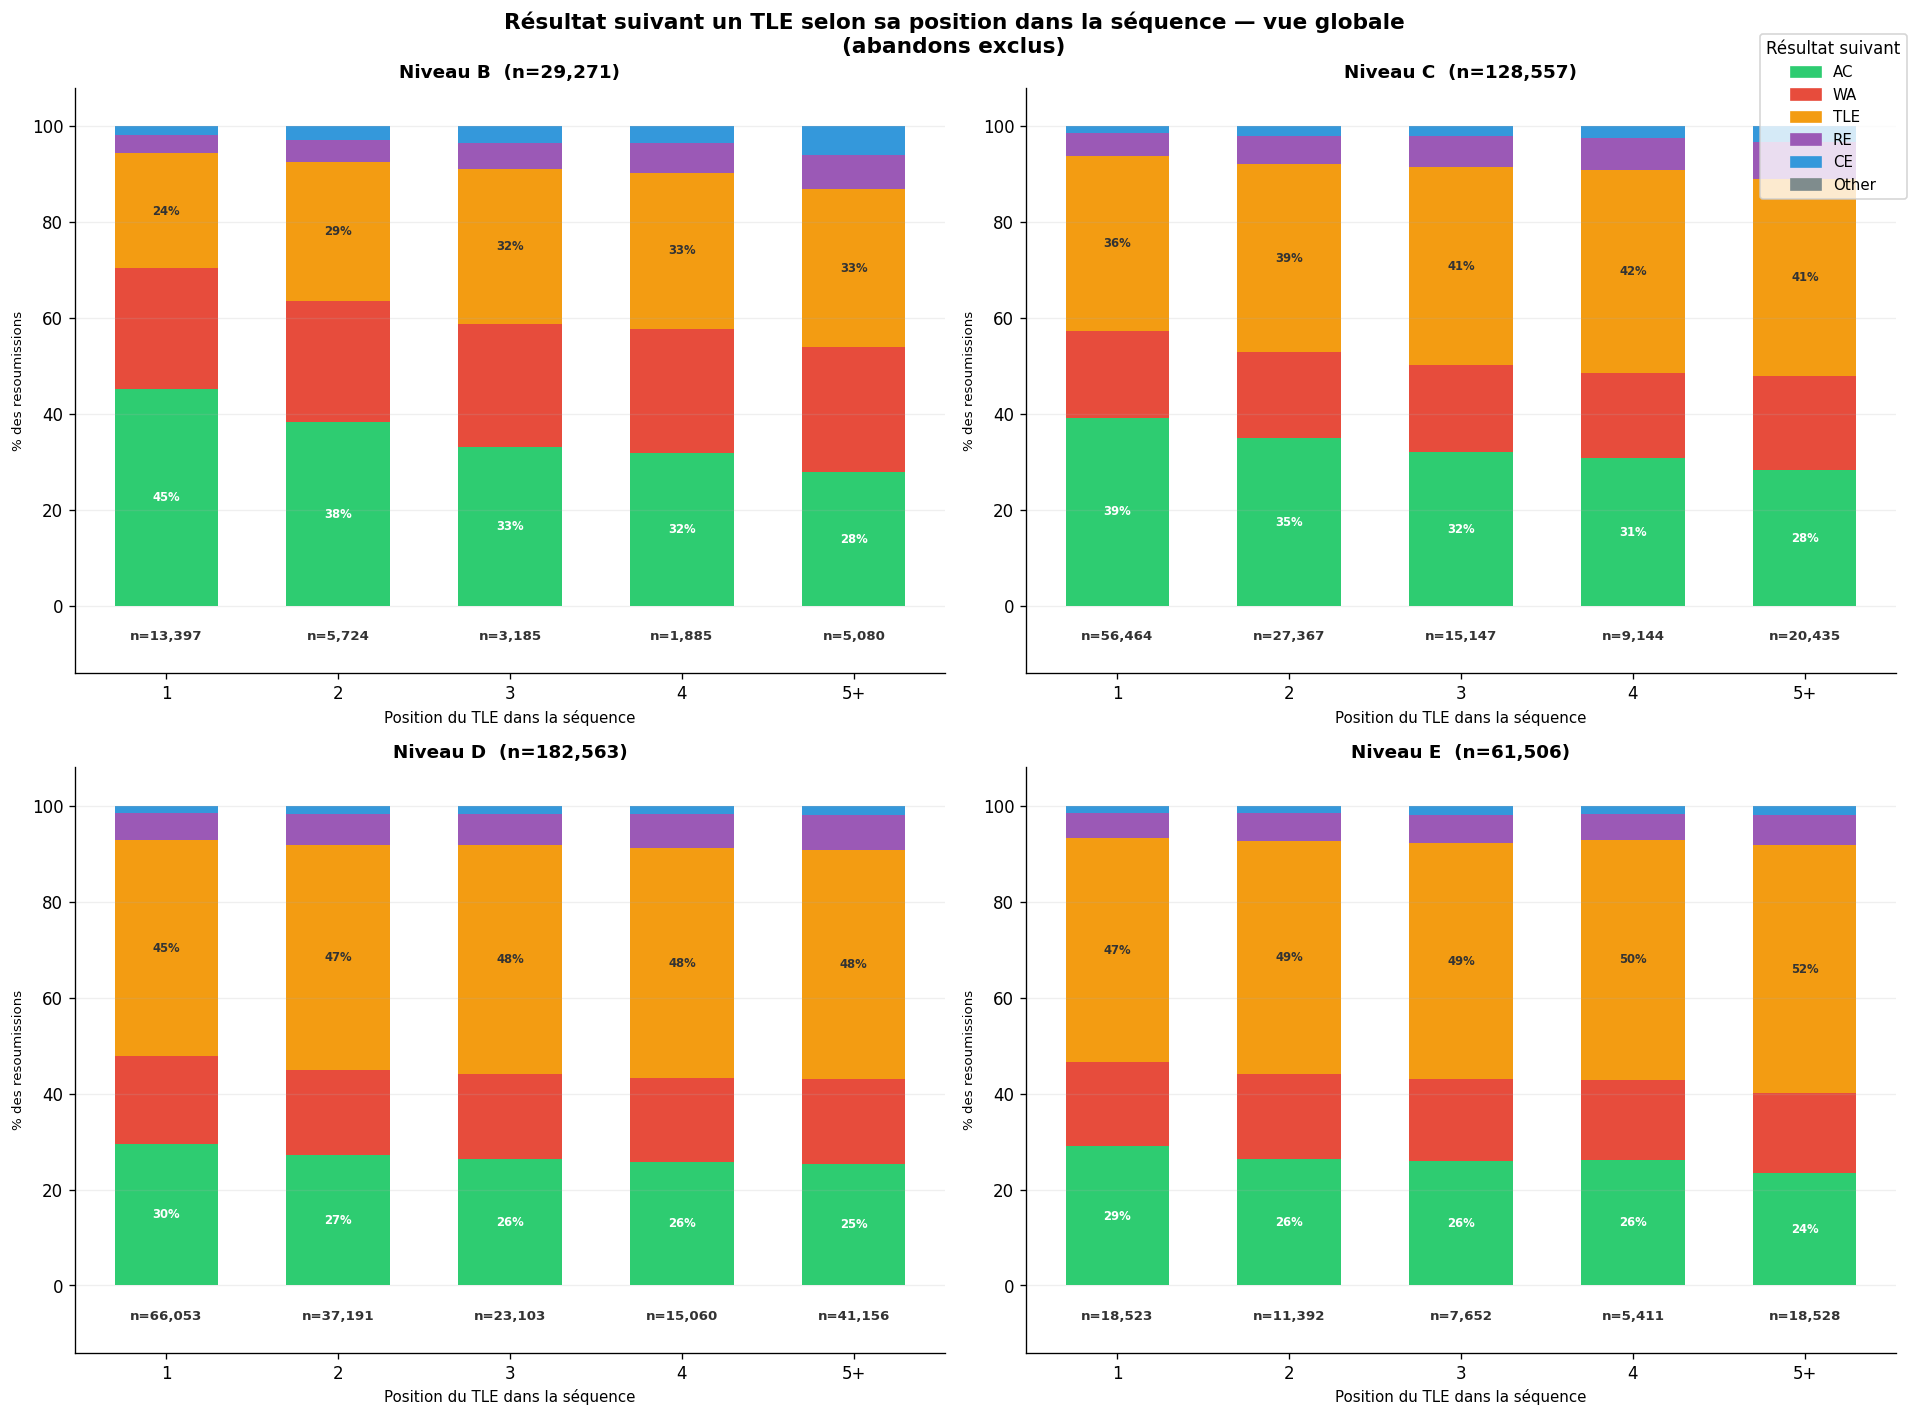

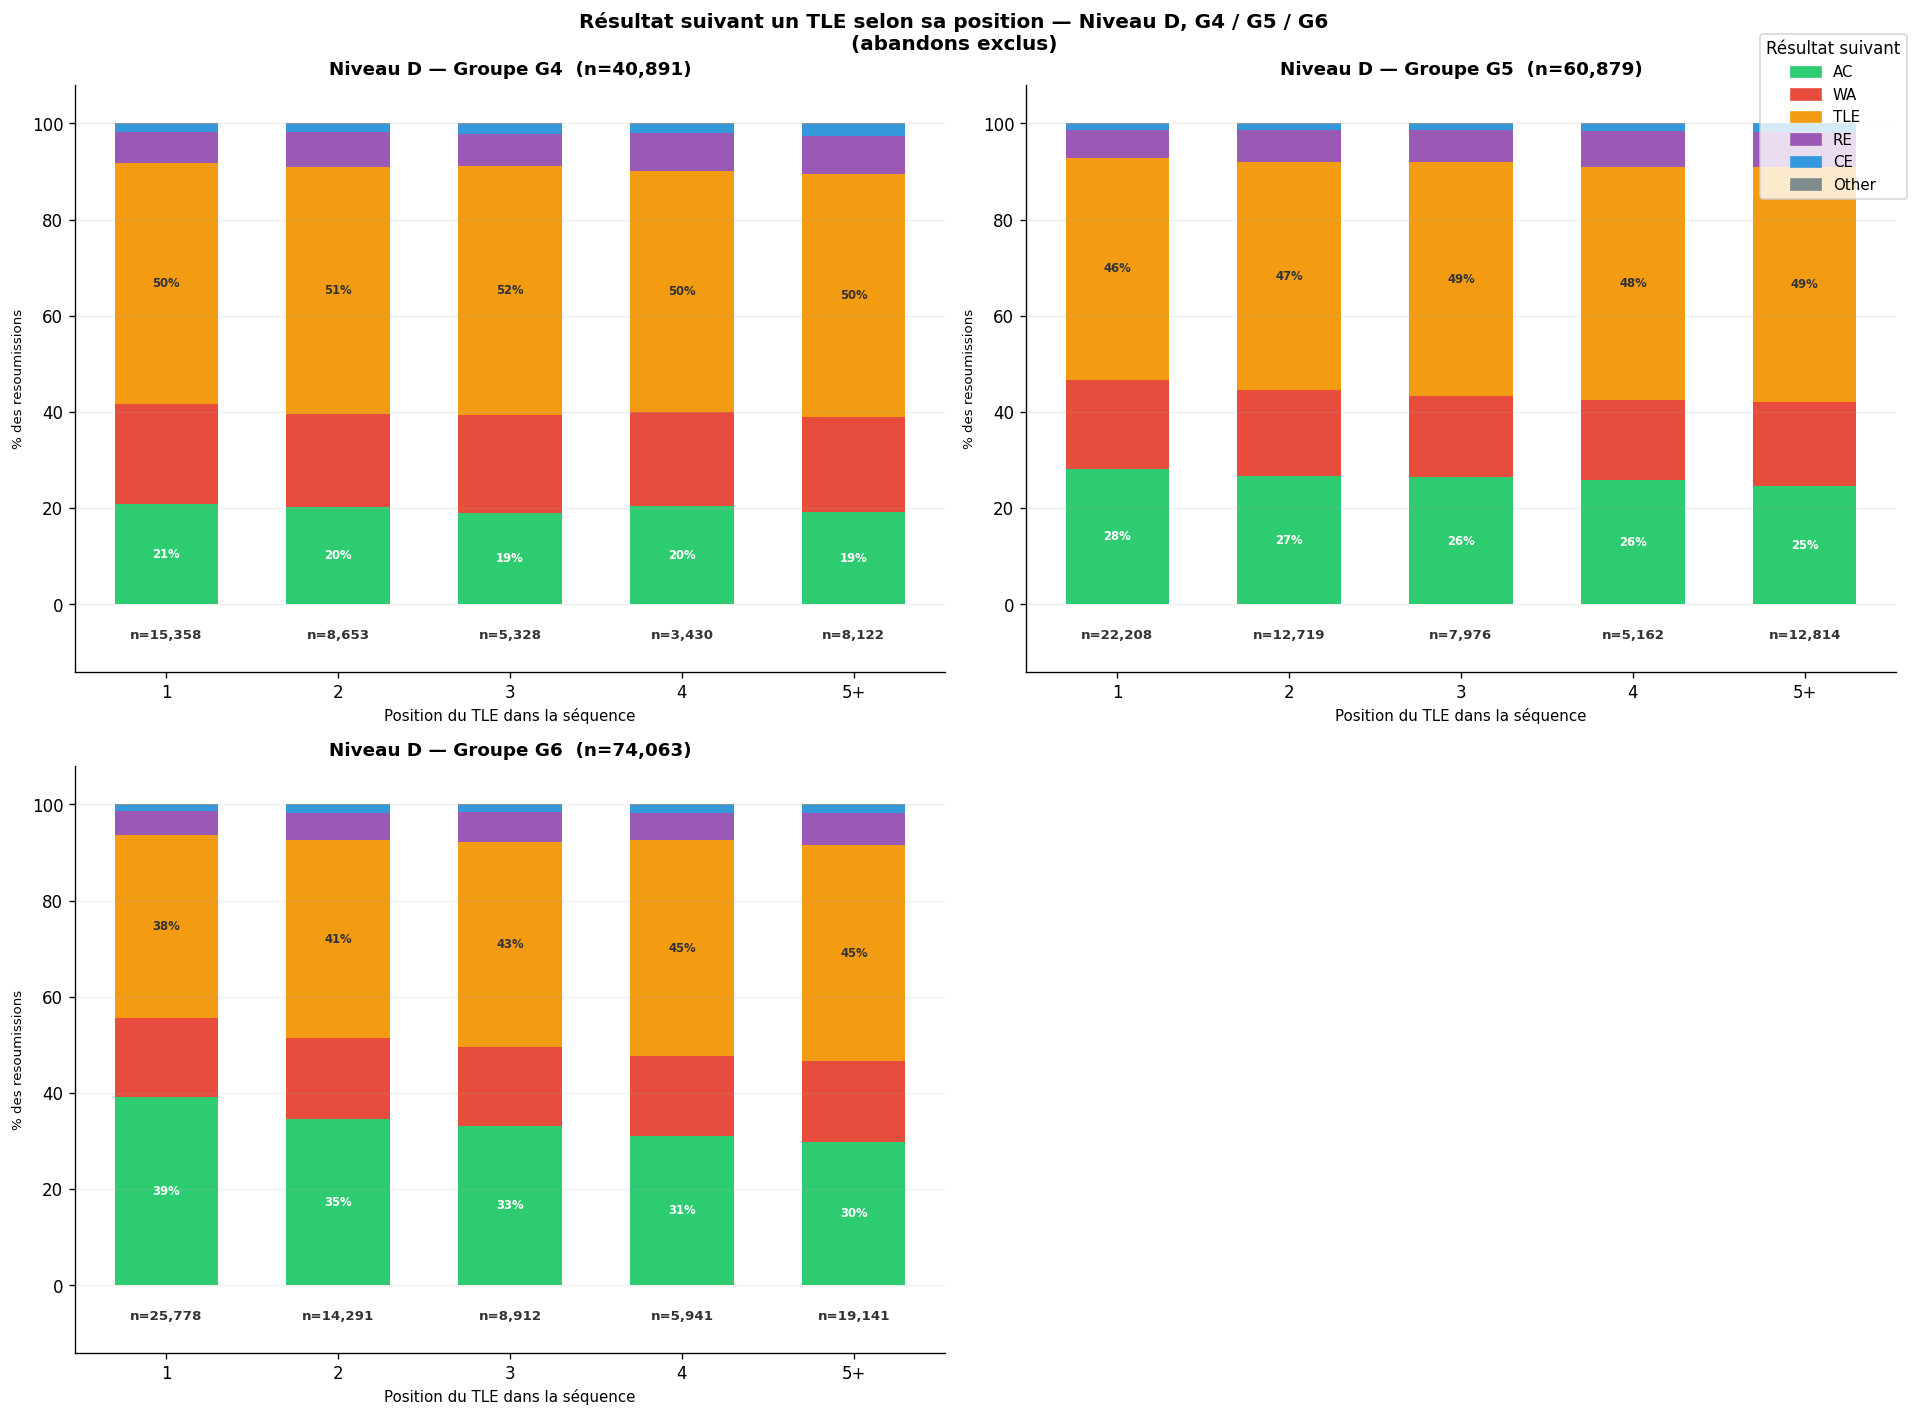

In [10]:
RANK_LABELS = ['1', '2', '3', '4', '5+']
STATUS_OUTCOMES = ['AC', 'WA', 'TLE', 'RE', 'CE', 'Other']

df_s2 = df.filter(pl.col('next_status') != 'Abandon').with_columns(
    pl.when(pl.col('submission_rank') >= 5)
      .then(pl.lit('5+'))
      .otherwise(pl.col('submission_rank').cast(pl.Utf8))
      .alias('rank_label')
)


def plot_s2(df_input, title, ax):
    bin_counts = {}
    bin_totals = {}
    for label in RANK_LABELS:
        sub = df_input.filter(pl.col('rank_label') == label)
        bin_totals[label] = max(sub.height, 1)
        bin_counts[label] = {s: sub.filter(pl.col('next_status') == s).height
                              for s in STATUS_OUTCOMES}

    bottoms = np.zeros(len(RANK_LABELS))
    for status in STATUS_OUTCOMES:
        pcts = np.array([
            100 * bin_counts[l][status] / bin_totals[l]
            for l in RANK_LABELS
        ])
        ax.bar(RANK_LABELS, pcts, bottom=bottoms,
               color=STATUS_COLORS[status], label=status, width=0.6)
        for s_ann in ['AC', 'TLE']:
            if status == s_ann:
                for i, (pct, bot) in enumerate(zip(pcts, bottoms)):
                    if pct > 5:
                        ax.text(i, bot + pct / 2, f'{pct:.0f}%',
                                ha='center', va='center', fontsize=7,
                                fontweight='bold',
                                color='white' if status == 'AC' else '#333')
        bottoms += pcts

    for i, label in enumerate(RANK_LABELS):
        n = bin_totals[label]
        clr = '#c0392b' if n < 150 else '#333'
        ax.text(i, -5, f'n={n:,}', ha='center', va='top', fontsize=8,
                fontweight='bold', color=clr)

    ax.set_ylim(-14, 108)
    ax.set_xlabel('Position du TLE dans la séquence', fontsize=9)
    ax.set_ylabel('% des resoumissions', fontsize=8)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.grid(axis='y', alpha=0.2)


# Figure 1 : vue globale par niveau (B, C, D, E) — 2 par ligne
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()
for ax, diff in zip(axes, ['B', 'C', 'D', 'E']):
    sub = df_s2.filter(pl.col('difficulty') == diff)
    plot_s2(sub, f'Niveau {diff}  (n={sub.height:,})', ax)

handles = [mpatches.Patch(color=STATUS_COLORS[s], label=s) for s in STATUS_OUTCOMES]
fig.legend(handles=handles, title='Résultat suivant', loc='upper right',
           ncol=1, fontsize=9, bbox_to_anchor=(1.0, 0.97))
fig.suptitle(
    'Résultat suivant un TLE selon sa position dans la séquence — vue globale\n'
    '(abandons exclus)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()


# Figure 2 : niveau D par groupe (G4, G5, G6) — 2 par ligne
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()
for ax, grp in zip(axes, ['G4', 'G5', 'G6']):
    sub = df_s2.filter((pl.col('difficulty') == 'D') & (pl.col('proficiency_group') == grp))
    plot_s2(sub, f'Niveau D — Groupe {grp}  (n={sub.height:,})', ax)
axes[3].set_visible(False)

handles = [mpatches.Patch(color=STATUS_COLORS[s], label=s) for s in STATUS_OUTCOMES]
fig.legend(handles=handles, title='Résultat suivant', loc='upper right',
           ncol=1, fontsize=9, bbox_to_anchor=(1.0, 0.97))
fig.suptitle(
    'Résultat suivant un TLE selon sa position — Niveau D, G4 / G5 / G6\n'
    '(abandons exclus)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()

*Analyse à compléter après exécution / Analysis to be filled after running.*

---
## Synthèse — Originalité et solidité des résultats
## Synthesis — Originality and Robustness of Findings

### Les 5 findings principaux, par ordre d'intérêt

1. **L'anomalie 2–5 min sur D/E/F.** Finding contre-intuitif, empiriquement solide (n > 37 000 pour D). Cohérent avec un modèle de "patch précipité sans diagnostic" : les utilisateurs qui soumettent entre 2 et 5 min font une correction hasardeuse sans avoir identifié la cause algorithmique. C'est le seul résultat qui n'était pas prévisible a priori.

2. **G6 sur B = effet temporel inversé (–4,4 pp).** La relation délai → performance n'est pas universelle : elle s'inverse pour les experts sur des problèmes faciles. Parmi les G6 qui prennent > 2h sur un TLE de niveau B, quelque chose est systématiquement anormal (perte de contexte, abandon mental). Nuance importante pour toute interprétation pédagogique générale.

3. **F/G5 = plafond de capacité absolu (0 % AC, tous délais).** Aucun investissement temporel ne compense un déficit algorithmique fondamental. Quantifie empiriquement un *ceiling effect* et permet de définir des seuils de compétence requis par niveau.

4. **Convergence inter-groupe à > 2h.** L'écart G3–G6 passe de ~20 pp (bin 0–2 min) à ~5 pp (bin > 2h) sur les niveaux B et C. Implication pédagogique forte : donner plus de temps réduit l'effet du niveau de compétence de base, notamment pour les apprenants faibles (G3).

5. **Orthogonalité position × délai, modulée par le groupe.** Pour G4 sur D : seulement le délai compte, la position est sans effet (Δ = –1,6 pp pos1→5+). Pour G6 sur D : les deux dimensions contribuent (Δ temporel +8–12 pp, Δ positionnel –9,3 pp pos1→5+). Ces deux axes mesurent des phénomènes distincts.

---

### Ce qui est solide

Les effectifs sur B/C/D sont très grands (27 K–172 K). Les patterns intra-niveau sont cohérents entre groupes. L'anomalie 2–5 min est répliquée sur trois niveaux indépendants (D, E, F).

### Ce qui est fragile

E et F ont des effectifs 3–7× inférieurs à D. Les résultats E/G5, F/G5, F/G6 reposent sur quelques centaines à quelques milliers d'observations. Les cellules extrêmes (E/G6 × > 2h, F × pos 5+) peuvent avoir n < 100 dans certains bins — repérable à l'affichage en rouge des effectifs sous les barres.

---

### Top 5 findings, ranked by significance

1. **The 2–5 min anomaly on D/E/F.** Counter-intuitive, empirically solid (n > 37,000 for D). Consistent with a "blind patch without diagnosis" model: users who resubmit within 2–5 min apply a hasty fix without having identified the algorithmic root cause. The only result that was not predictable a priori.

2. **G6 on B = reversed temporal effect (–4.4 pp).** The delay → performance relationship is not universal: it reverses for experts on easy problems. Among G6 users taking > 2h on a level-B TLE, something is systematically abnormal (loss of context, mental abandon). An important nuance for any general pedagogical interpretation.

3. **F/G5 = absolute capability ceiling (0% AC, all delays).** No amount of time investment compensates for a fundamental algorithmic deficit. Empirically quantifies a *ceiling effect* and allows defining minimum competency thresholds per difficulty level.

4. **Inter-group convergence at > 2h.** The G3–G6 gap shrinks from ~20 pp (0–2 min bin) to ~5 pp (> 2h bin) at levels B and C. Strong pedagogical implication: giving more time reduces the effect of baseline skill level, particularly for weaker learners (G3).

5. **Orthogonality of position × delay, modulated by group.** For G4 on D: only delay matters, position has no effect (Δ = –1.6 pp pos1→5+). For G6 on D: both dimensions contribute (Δ temporal +8–12 pp, Δ positional –9.3 pp pos1→5+). These two axes measure distinct phenomena.

---

### What is robust

Sample sizes on B/C/D are very large (27K–172K). Within-level patterns are consistent across groups. The 2–5 min anomaly is replicated across three independent levels (D, E, F).

### What is fragile

E and F have sample sizes 3–7× smaller than D. Results for E/G5, F/G5, F/G6 rely on a few hundred to a few thousand observations. Extreme cells (E/G6 × > 2h, F × pos 5+) can have n < 100 in some bins — flagged by the red sample size labels below the bars.